# India Air Quality Analysis (2015-2023)

**Author:** Chintakindi Jasnavi  
**Date:** 2026  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

## Problem Statement
India's rapid urbanization has led to alarming levels of air pollution. This project analyzes 9 years of daily AQI data across 8 major Indian cities to identify pollution trends, seasonal patterns, COVID lockdown impact and dominant pollutants.

## Cities Covered
Delhi, Mumbai, Chennai, Bengaluru, Hyderabad, Ahmedabad, Pune, Lucknow

## Section 1 — Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly
import scipy
import statsmodels

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("sklearn:", sklearn.__version__)
print("plotly:", plotly.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("All libraries installed successfully! ✅")

numpy: 2.4.2
pandas: 3.0.0
matplotlib: 3.10.8
seaborn: 0.13.2
sklearn: 1.8.0
plotly: 6.5.2
scipy: 1.17.0
statsmodels: 0.14.6
All libraries installed successfully! ✅


## Section 2 — Load Data

In [6]:
# Load all sheets at once and combine
df = pd.concat(pd.read_excel(r"C:\Users\chint\OneDrive\Desktop\Data\aqlbulletins.xlsx", 
               sheet_name=None).values(), ignore_index=True)



In [7]:

df.shape
df.size
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23665 entries, 0 to 23664
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 23665 non-null  datetime64[us]
 1   City                 23665 non-null  str           
 2   No. Stations         23588 non-null  float64       
 3   Air Quality          23665 non-null  str           
 4   Index Value          23665 non-null  int64         
 5   Prominent Pollutant  23665 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 1.1 MB


In [8]:
df.head()


,date,City,No. Stations,Air Quality,Index Value,Prominent Pollutant
0,2015-05-01,Hyderabad,NaN,Moderate,189,PM2.5
1,2015-05-02,Hyderabad,NaN,Satisfactory,94,PM2.5
2,2015-05-03,Hyderabad,NaN,Satisfactory,66,PM2.5
3,2015-05-04,Hyderabad,NaN,Satisfactory,77,PM2.5
4,2015-05-05,Hyderabad,NaN,Satisfactory,68,PM2.5


In [9]:
df.tail()

,date,City,No. Stations,Air Quality,Index Value,Prominent Pollutant
23660,2023-12-27,Lucknow,4.0,Poor,217,PM2.5
23661,2023-12-28,Lucknow,6.0,Moderate,149,PM2.5
23662,2023-12-29,Lucknow,6.0,Moderate,182,PM2.5
23663,2023-12-30,Lucknow,6.0,Moderate,140,"PM10, PM2.5"
23664,2023-12-31,Lucknow,6.0,Moderate,109,"PM10, PM2.5"


In [10]:
df.describe()

,date,No. Stations,Index Value
count,23665,23588.000000,23665.000000
mean,2019-10-26 07:09:35.787027,7.644989,125.729009
min,2015-05-01 00:00:00,1.000000,14.000000
25%,2017-10-05 00:00:00,2.000000,68.000000
50%,2019-11-12 00:00:00,5.000000,99.000000
75%,2021-12-01 00:00:00,8.000000,158.000000
max,2023-12-31 00:00:00,39.000000,500.000000
std,NaN,9.011920,82.359281


In [11]:

df.isnull().sum()

date                    0
City                    0
No. Stations           77
Air Quality             0
Index Value             0
Prominent Pollutant     0
dtype: int64

In [12]:
df.dtypes

date                   datetime64[us]
City                              str
No. Stations                  float64
Air Quality                       str
Index Value                     int64
Prominent Pollutant               str
dtype: object

In [13]:

print(df['City'].unique())
print(df['City'].value_counts())

<StringArray>
['Hyderabad',   'Chennai', 'Bengaluru',      'Pune',    'Mumbai', 'Ahmedabad',
     'Delhi',   'Lucknow']
Length: 8, dtype: str
City
Delhi        3143
Hyderabad    3132
Bengaluru    3120
Chennai      3074
Lucknow      3056
Mumbai       2884
Pune         2718
Ahmedabad    2538
Name: count, dtype: int64


In [14]:

print("\nDate Range:")
print("Start:", df['date'].min())
print("End:", df['date'].max())



Date Range:
Start: 2015-05-01 00:00:00
End: 2023-12-31 00:00:00


In [15]:
delhi_missing=df[(df['City']=='Delhi')&(df['No. Stations'].isnull())]
print(delhi_missing[['City','date','No. Stations']].head(20))

        City       date  No. Stations
17466  Delhi 2015-05-01           NaN
17467  Delhi 2015-05-02           NaN
17468  Delhi 2015-05-03           NaN
17469  Delhi 2015-05-04           NaN
17470  Delhi 2015-05-05           NaN
17471  Delhi 2015-05-06           NaN
17472  Delhi 2015-05-07           NaN
17473  Delhi 2015-05-08           NaN
17474  Delhi 2015-05-09           NaN
17475  Delhi 2015-05-10           NaN
17476  Delhi 2015-05-11           NaN
17477  Delhi 2015-05-12           NaN
17478  Delhi 2015-05-13           NaN


In [16]:
print(df.groupby('City')['No. Stations'].apply(lambda x: x.isnull().sum()))

City
Ahmedabad    14
Bengaluru    12
Chennai      12
Delhi        13
Hyderabad    14
Lucknow      12
Mumbai        0
Pune          0
Name: No. Stations, dtype: int64


In [17]:
df['No. Stations'] = df.groupby('City')['No. Stations'].transform(lambda x: x.fillna(x.mode()[0])
)

In [18]:
print(df.isnull().sum())

date                   0
City                   0
No. Stations           0
Air Quality            0
Index Value            0
Prominent Pollutant    0
dtype: int64


In [19]:
print(df.groupby('City')['No. Stations'].value_counts())

City       No. Stations
Ahmedabad  1.0             1735
           7.0              197
           9.0              186
           8.0              184
           6.0              120
                           ... 
Pune       4.0              173
           3.0              163
           7.0              124
           2.0               66
           8.0               42
Name: count, Length: 124, dtype: int64


In [20]:
print(df.shape)

(23665, 6)


In [21]:


df['date'] = pd.to_datetime(df['date'])

df['No. Stations'] = df.groupby('City')['No. Stations'].transform(
    lambda x: x.fillna(x.mode()[0])
)

df = df.rename(columns={'Index Value': 'AQI'})

df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Month_Name'] = df['date'].dt.strftime('%b')
df['Season'] = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Summer', 4:'Summer', 5:'Summer',
    6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
    10:'Post-Monsoon', 11:'Post-Monsoon'
})

print(df.shape)
print(df['City'].unique())

(23665, 10)
<StringArray>
['Hyderabad',   'Chennai', 'Bengaluru',      'Pune',    'Mumbai', 'Ahmedabad',
     'Delhi',   'Lucknow']
Length: 8, dtype: str


In [22]:
print(df.columns)

Index(['date', 'City', 'No. Stations', 'Air Quality', 'AQI',
       'Prominent Pollutant', 'Year', 'Month', 'Month_Name', 'Season'],
      dtype='str')


In [23]:
print(df.head)

<bound method NDFrame.head of             date       City  No. Stations   Air Quality  AQI  \
0     2015-05-01  Hyderabad           6.0      Moderate  189   
1     2015-05-02  Hyderabad           6.0  Satisfactory   94   
2     2015-05-03  Hyderabad           6.0  Satisfactory   66   
3     2015-05-04  Hyderabad           6.0  Satisfactory   77   
4     2015-05-05  Hyderabad           6.0  Satisfactory   68   
...          ...        ...           ...           ...  ...   
23660 2023-12-27    Lucknow           4.0          Poor  217   
23661 2023-12-28    Lucknow           6.0      Moderate  149   
23662 2023-12-29    Lucknow           6.0      Moderate  182   
23663 2023-12-30    Lucknow           6.0      Moderate  140   
23664 2023-12-31    Lucknow           6.0      Moderate  109   

      Prominent Pollutant  Year  Month Month_Name  Season  
0                   PM2.5  2015      5        May  Summer  
1                   PM2.5  2015      5        May  Summer  
2                   P

In [ ]:
df=df.rename(columns={'Index Value':'AQI'})

In [43]:
df.columns

Index(['date', 'City', 'No. Stations', 'Air Quality', 'AQI',
       'Prominent Pollutant', 'Year', 'Month', 'Month_Name', 'Season'],
      dtype='str')

Section 3 — Exploratory Data Analysis (EDA)

In [37]:
city_avg = df.groupby('City')['AQI'].mean().round(2).sort_values(ascending=False)
print(city_avg)

City
Delhi        217.14
Lucknow      181.16
Ahmedabad    134.11
Pune         109.59
Mumbai       108.16
Hyderabad     91.80
Chennai       86.63
Bengaluru     75.42
Name: AQI, dtype: float64


In [38]:
yearly = df.groupby(['City','Year'])['AQI'].mean().round(2).reset_index()
print(yearly)

         City  Year     AQI
0   Ahmedabad  2015  116.74
1   Ahmedabad  2016  163.31
2   Ahmedabad  2017  197.27
3   Ahmedabad  2018  158.13
4   Ahmedabad  2019  152.55
..        ...   ...     ...
67       Pune  2019  109.17
68       Pune  2020   85.44
69       Pune  2021   95.68
70       Pune  2022  116.62
71       Pune  2023  123.93

[72 rows x 3 columns]


In [39]:
print(df.groupby('Season')['AQI'].mean().round(2).sort_values(ascending=False))
print(df.groupby('Month_Name')['AQI'].mean().round(2).sort_values(ascending=False))

Season
Winter          170.99
Post-Monsoon    155.54
Summer          123.70
Monsoon          79.64
Name: AQI, dtype: float64
Month_Name
Dec    178.10
Jan    175.70
Nov    175.52
Feb    157.24
Oct    135.75
Mar    133.57
Apr    123.47
May    114.73
Jun     94.33
Sep     79.30
Jul     74.35
Aug     71.59
Name: AQI, dtype: float64


In [40]:
covid = df[(df['date']>='2020-03-25') & (df['date']<='2020-05-31')]
pre = df[(df['date']>='2019-03-25') & (df['date']<='2019-05-31')]
print("2019:", pre.groupby('City')['AQI'].mean().round(2))
print("2020:", covid.groupby('City')['AQI'].mean().round(2))

2019: City
Ahmedabad    162.71
Bengaluru    107.21
Chennai       82.87
Delhi        213.40
Hyderabad    102.34
Lucknow      191.41
Mumbai        91.97
Pune          95.83
Name: AQI, dtype: float64
2020: City
Ahmedabad    129.44
Bengaluru     58.12
Chennai       53.21
Delhi        121.21
Hyderabad     69.13
Lucknow      106.87
Mumbai        63.15
Pune          60.44
Name: AQI, dtype: float64


In [41]:
print(df.groupby('Prominent Pollutant').size().sort_values(ascending=False).head(10))

Prominent Pollutant
PM2.5              6045
PM10, PM2.5        4491
PM10               2567
CO                 1047
O3, PM2.5          1023
CO, PM2.5          1022
CO, PM10, PM2.5     932
CO, PM10            875
O3, PM10, PM2.5     574
O3, PM10            455
dtype: int64


In [42]:
print(df[df['Air Quality']=='Good'].groupby('City').size().sort_values(ascending=False))
print(df[df['Air Quality']=='Severe'].groupby('City').size().sort_values(ascending=False))

City
Bengaluru    632
Hyderabad    561
Mumbai       342
Chennai      335
Lucknow      119
Pune          93
Ahmedabad     49
Delhi         14
dtype: int64
City
Delhi        147
Lucknow       77
Ahmedabad      3
Hyderabad      1
Mumbai         1
Pune           1
dtype: int64


## Section 4 — Visualizations

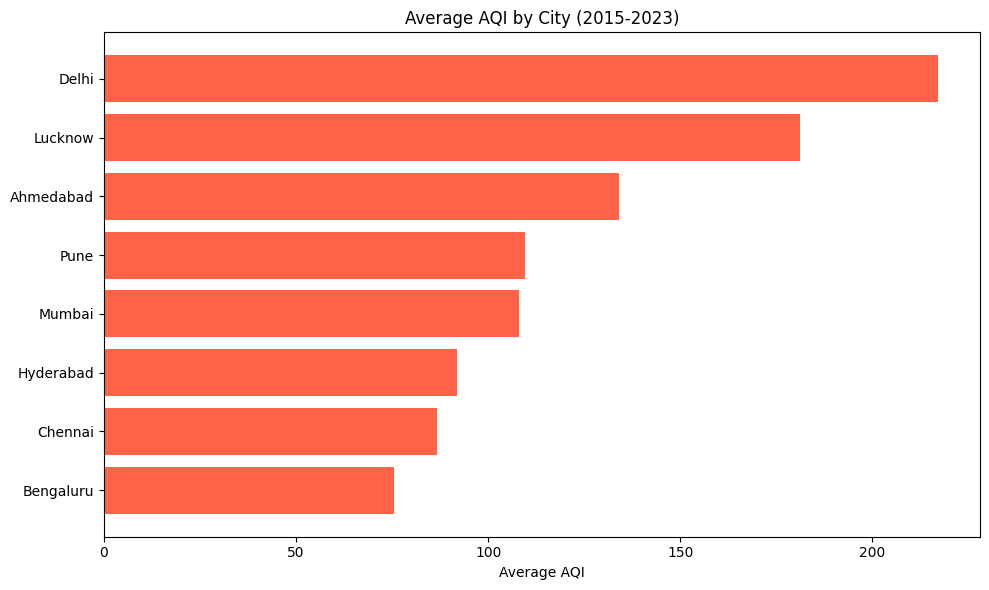

In [25]:
city_avg = df.groupby('City')['AQI'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.barh(city_avg.index[::-1], city_avg.values[::-1], color='tomato')
plt.title('Average AQI by City (2015-2023)')
plt.xlabel('Average AQI')
plt.tight_layout()
plt.show()

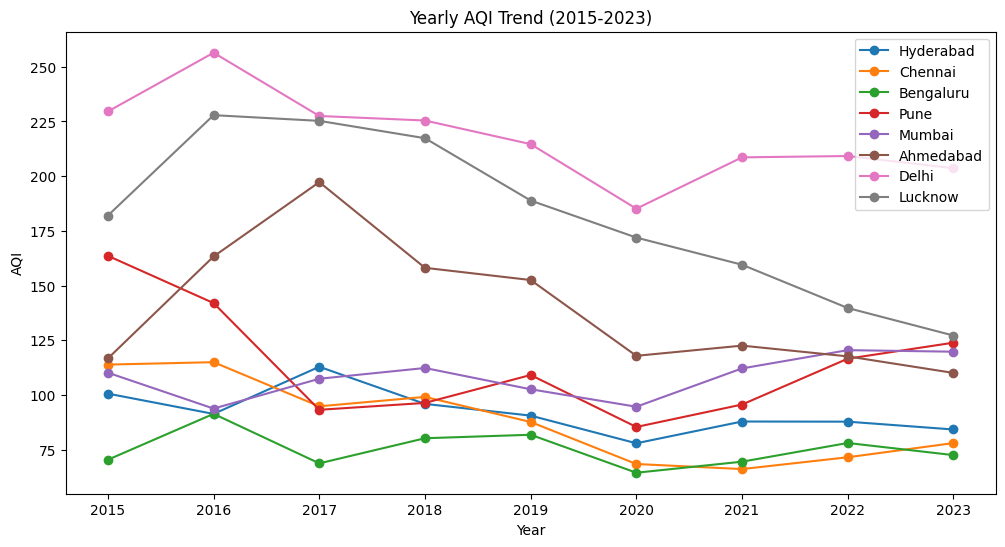

In [26]:
yearly_avg = df.groupby(['Year','City'])['AQI'].mean().round(2).reset_index()

plt.figure(figsize=(12,6))
for city in df['City'].unique():
    data = yearly_avg[yearly_avg['City']==city]
    plt.plot(data['Year'], data['AQI'], marker='o', label=city)

plt.title('Yearly AQI Trend (2015-2023)')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.legend()
plt.show()

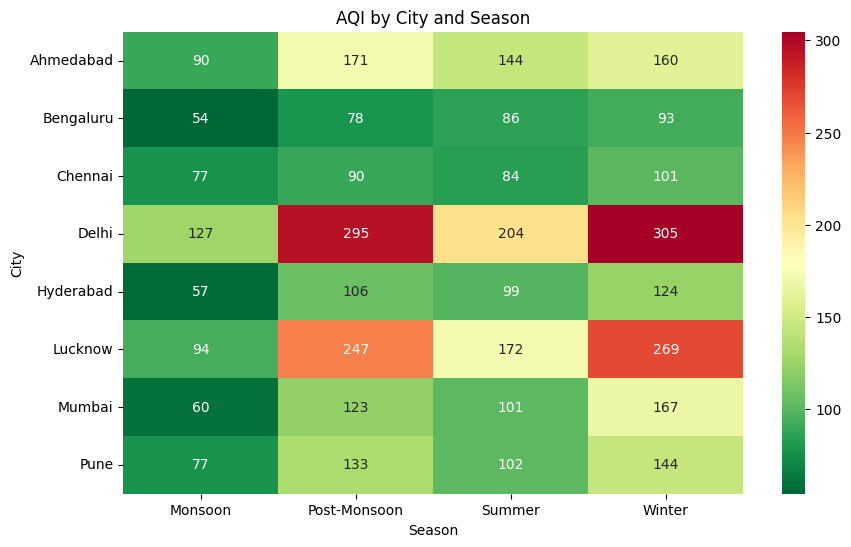

In [27]:
seasonal = df.groupby(['City','Season'])['AQI'].mean().round(2).reset_index()
pivot = seasonal.pivot(index='City', columns='Season', values='AQI')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r')
plt.title('AQI by City and Season')
plt.show()

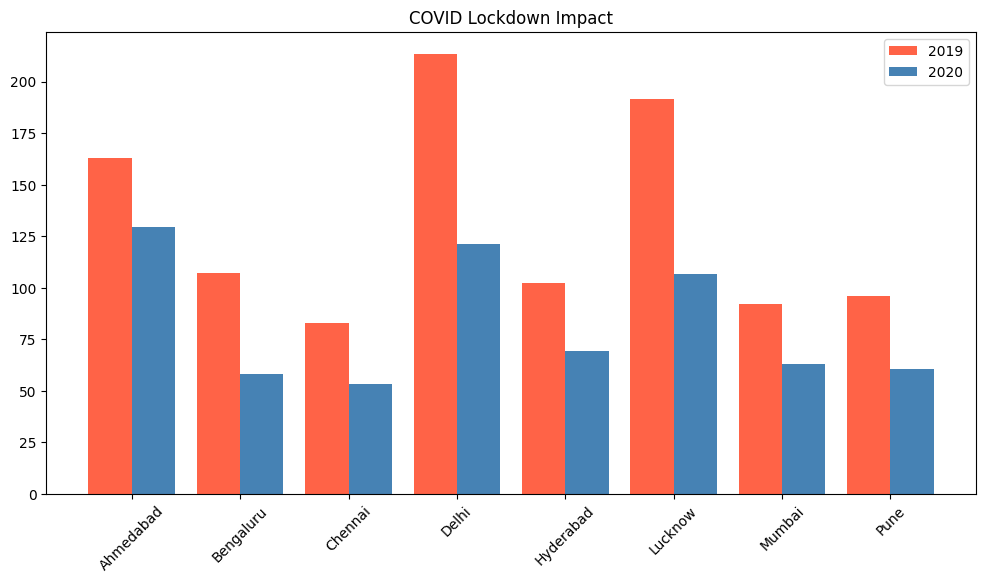

In [28]:
covid = df[(df['date']>='2020-03-25') & (df['date']<='2020-05-31')]
pre = df[(df['date']>='2019-03-25') & (df['date']<='2019-05-31')]

covid_avg = covid.groupby('City')['AQI'].mean().round(2)
pre_avg = pre.groupby('City')['AQI'].mean().round(2)

x = range(len(covid_avg))
plt.figure(figsize=(12,6))
plt.bar([i-0.2 for i in x], pre_avg, width=0.4, label='2019', color='tomato')
plt.bar([i+0.2 for i in x], covid_avg, width=0.4, label='2020', color='steelblue')
plt.xticks(x, covid_avg.index, rotation=45)
plt.title('COVID Lockdown Impact')
plt.legend()
plt.show()

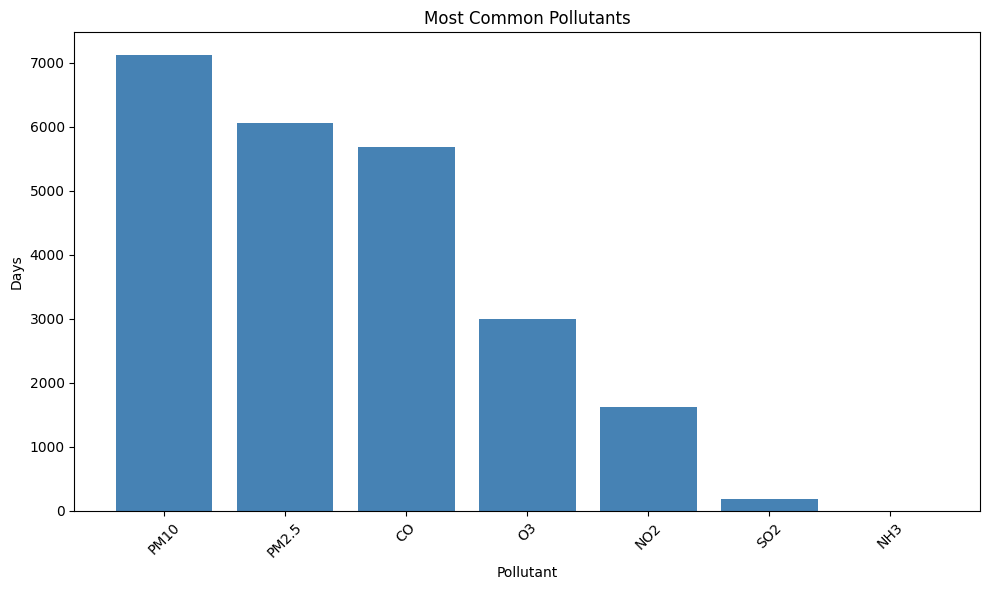

In [44]:
# Extract only first pollutant from combinations
df['Main Pollutant'] = df['Prominent Pollutant'].str.split(',').str[0].str.strip()
df['Main Pollutant'] = df['Main Pollutant'].replace('OZONE', 'O3')

pollutant = df.groupby('Main Pollutant').size().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(pollutant.index, pollutant.values, color='steelblue')
plt.title('Most Common Pollutants')
plt.xlabel('Pollutant')
plt.ylabel('Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

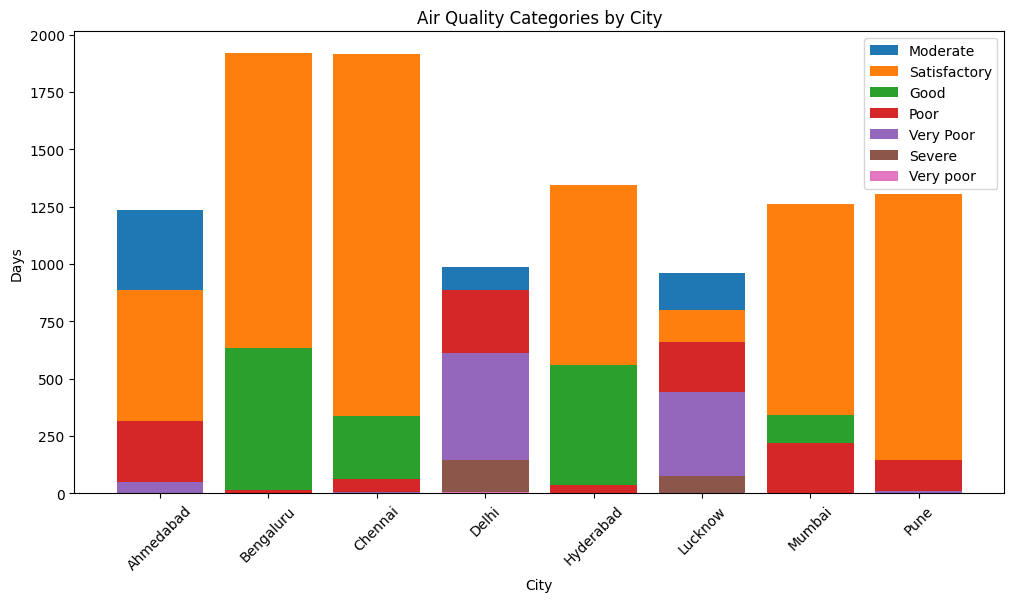

In [35]:
category = df.groupby(['City','Air Quality']).size().reset_index(name='Count')

plt.figure(figsize=(12,6))
for aq in df['Air Quality'].unique():
    data = category[category['Air Quality']==aq]
    plt.bar(data['City'], data['Count'], label=aq)

plt.title('Air Quality Categories by City')
plt.xlabel('City')
plt.ylabel('Days')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Section 5 — Summary

- Delhi is most polluted (AQI 217), Bengaluru is cleanest (AQI 75)
- Winter is worst season, Monsoon is cleanest
- COVID lockdown improved AQI by 20-46% in every city
- PM2.5 is the most dominant pollutant overall
- Delhi had only 14 Good days in 9 years